In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import alphashape
from itertools import combinations
from collections import defaultdict, deque
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor, as_completed


from shapely import points, contains
import random

In [2]:
#%pip install -e ..

In [16]:
from proj2dhullsampler import HistoryMatching
from proj2dhullsampler import plot_histograms_grid_5

In [4]:
working_dir = '/glade/work/qingyuany/camml_re'
case_name = "v2_extreme"

para = pd.read_csv("/glade/work/qingyuany/camml_re/v1_filter_extreme/post_simulation/post_paras.csv", index_col=0)
para.shape



(99, 34)

In [5]:
test_case = HistoryMatching(working_dir, case_name, para, threshold_level=2.0)
test_case.drop_by_name(["LWCF"])
test_case.drop_by_n_survive(n_survive = 100000)
test_case.update_meta()



In [6]:
test_case.group_para_climatology(overlapping_threshold = 10000)
summary2d = test_case.shuffle_vars()

clubb_c2rt                               and microp_aero_wsubi_scale                 :   324146
micro_mg_berg_eff_factor                 and microp_aero_npccn_scale                 :   392464
clubb_C8                                 and microp_aero_npccn_scale                 :   794581
micro_mg_berg_eff_factor                 and micro_mg_dcs                            :   285548
micro_mg_dcs                             and microp_aero_wsubi_scale                 :   577019
clubb_c2rt                               and microp_aero_wsub_scale                  :   742083
micro_mg_vtrmi_factor                    and clubb_c2rt                              :   796446
micro_mg_iaccr_factor                    and micro_mg_berg_eff_factor                :   553065
micro_mg_vtrmi_factor                    and micro_mg_dcs                            :   647750
clubb_c14                                and clubb_c2rt                              :   768627
micro_mg_vtrmi_factor                   

In [7]:
list(summary2d.values())[0]

IndexError: list index out of range

In [7]:
no_overlap_2d_vars = []

In [8]:
test_case.drop_no_overlap2d_vars(no_overlap_2d_vars)
test_case.group_para_climatology()
summary2d = test_case.shuffle_vars()
summary2d

clubb_c2rt                               and microp_aero_wsubi_scale                 :   324146
micro_mg_berg_eff_factor                 and microp_aero_npccn_scale                 :   392464
clubb_C8                                 and microp_aero_npccn_scale                 :   794581
micro_mg_berg_eff_factor                 and micro_mg_dcs                            :   285548
micro_mg_dcs                             and microp_aero_wsubi_scale                 :   577019
clubb_c2rt                               and microp_aero_wsub_scale                  :   742083
micro_mg_vtrmi_factor                    and clubb_c2rt                              :   796446
micro_mg_iaccr_factor                    and micro_mg_berg_eff_factor                :   553065
micro_mg_vtrmi_factor                    and micro_mg_dcs                            :   647750
clubb_c14                                and clubb_c2rt                              :   768627
micro_mg_vtrmi_factor                   

{}

In [9]:
test_case.paras_vars

{('clubb_c2rt', 'microp_aero_wsubi_scale'): ['PRECT_zonal_-15to-5',
  'FLUT_zonal_-15to-5',
  'FLUT_zonal_-5to5',
  'FLUT_zonal_-25to-15',
  'FLUT_zonal_5to15',
  'TMQ_zonal_5to15',
  'TMQ_zonal_25to35',
  'TMQ_zonal_15to25',
  'PRECT_zonal_-35to-25',
  'FLUT_zonal_15to25'],
 ('micro_mg_berg_eff_factor',
  'microp_aero_npccn_scale'): ['FSNTOA_zonal_-55to-45', 'FSNTOA_zonal_55to65', 'SWCF_zonal_-65to-55', 'SWCF_zonal_-55to-45', 'SWCF_zonal_65to75', 'SWCF_zonal_55to65'],
 ('clubb_C8', 'microp_aero_npccn_scale'): ['SWCF_zonal_-25to-15',
  'SWCF_zonal_-35to-25',
  'ave_SWCF',
  'FSNTOA_zonal_25to35',
  'FSNTOA_zonal_-35to-25',
  'ave_FSNTOA'],
 ('micro_mg_berg_eff_factor', 'micro_mg_dcs'): ['FSNTOA_zonal_45to55',
  'SWCF_zonal_45to55',
  'FLUT_zonal_55to65',
  'FLUT_zonal_-55to-45',
  'FLUT_zonal_65to75'],
 ('micro_mg_dcs', 'microp_aero_wsubi_scale'): ['FLUT_zonal_25to35',
  'ave_LWCF',
  'FLUT_zonal_-45to-35'],
 ('clubb_c2rt', 'microp_aero_wsub_scale'): ['TMQ_zonal_-5to5',
  'TMQ_zonal_-1

In [10]:
test_case.drop_by_nvar_per_pair(n_var_thre=1)

In [11]:
test_case.paras_vars

{('clubb_c2rt', 'microp_aero_wsubi_scale'): ['PRECT_zonal_-15to-5',
  'FLUT_zonal_-15to-5',
  'FLUT_zonal_-5to5',
  'FLUT_zonal_-25to-15',
  'FLUT_zonal_5to15',
  'TMQ_zonal_5to15',
  'TMQ_zonal_25to35',
  'TMQ_zonal_15to25',
  'PRECT_zonal_-35to-25',
  'FLUT_zonal_15to25'],
 ('micro_mg_berg_eff_factor',
  'microp_aero_npccn_scale'): ['FSNTOA_zonal_-55to-45', 'FSNTOA_zonal_55to65', 'SWCF_zonal_-65to-55', 'SWCF_zonal_-55to-45', 'SWCF_zonal_65to75', 'SWCF_zonal_55to65'],
 ('clubb_C8', 'microp_aero_npccn_scale'): ['SWCF_zonal_-25to-15',
  'SWCF_zonal_-35to-25',
  'ave_SWCF',
  'FSNTOA_zonal_25to35',
  'FSNTOA_zonal_-35to-25',
  'ave_FSNTOA'],
 ('micro_mg_berg_eff_factor', 'micro_mg_dcs'): ['FSNTOA_zonal_45to55',
  'SWCF_zonal_45to55',
  'FLUT_zonal_55to65',
  'FLUT_zonal_-55to-45',
  'FLUT_zonal_65to75'],
 ('micro_mg_dcs', 'microp_aero_wsubi_scale'): ['FLUT_zonal_25to35',
  'ave_LWCF',
  'FLUT_zonal_-45to-35'],
 ('clubb_c2rt', 'microp_aero_wsub_scale'): ['TMQ_zonal_-5to5',
  'TMQ_zonal_-1

In [12]:
test_case.build_hulls()

In [13]:
test_case.orchestrate()

Running ('clubb_c2rt', 'microp_aero_wsubi_scale'), the 0th simulation
There is overlap for ('clubb_c2rt', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('micro_mg_berg_eff_factor', 'microp_aero_npccn_scale'), the 1th simulation
There is overlap for ('micro_mg_berg_eff_factor', 'microp_aero_npccn_scale'). Proceed to the next parameter pair
Running ('clubb_C8', 'microp_aero_npccn_scale'), the 2th simulation
There is overlap for ('clubb_C8', 'microp_aero_npccn_scale'). Proceed to the next parameter pair
Running ('micro_mg_berg_eff_factor', 'micro_mg_dcs'), the 3th simulation
There is overlap for ('micro_mg_berg_eff_factor', 'micro_mg_dcs'). Proceed to the next parameter pair
Running ('micro_mg_dcs', 'microp_aero_wsubi_scale'), the 4th simulation
There is overlap for ('micro_mg_dcs', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('clubb_c2rt', 'microp_aero_wsub_scale'), the 5th simulation
There is overlap for ('clubb_c2rt', 'microp_aero_wsu

In [14]:
test_case.draw(n_pts=50000, n_threshold=5000, sample_threshold=10**8, max_workers=10, n_max=1000)

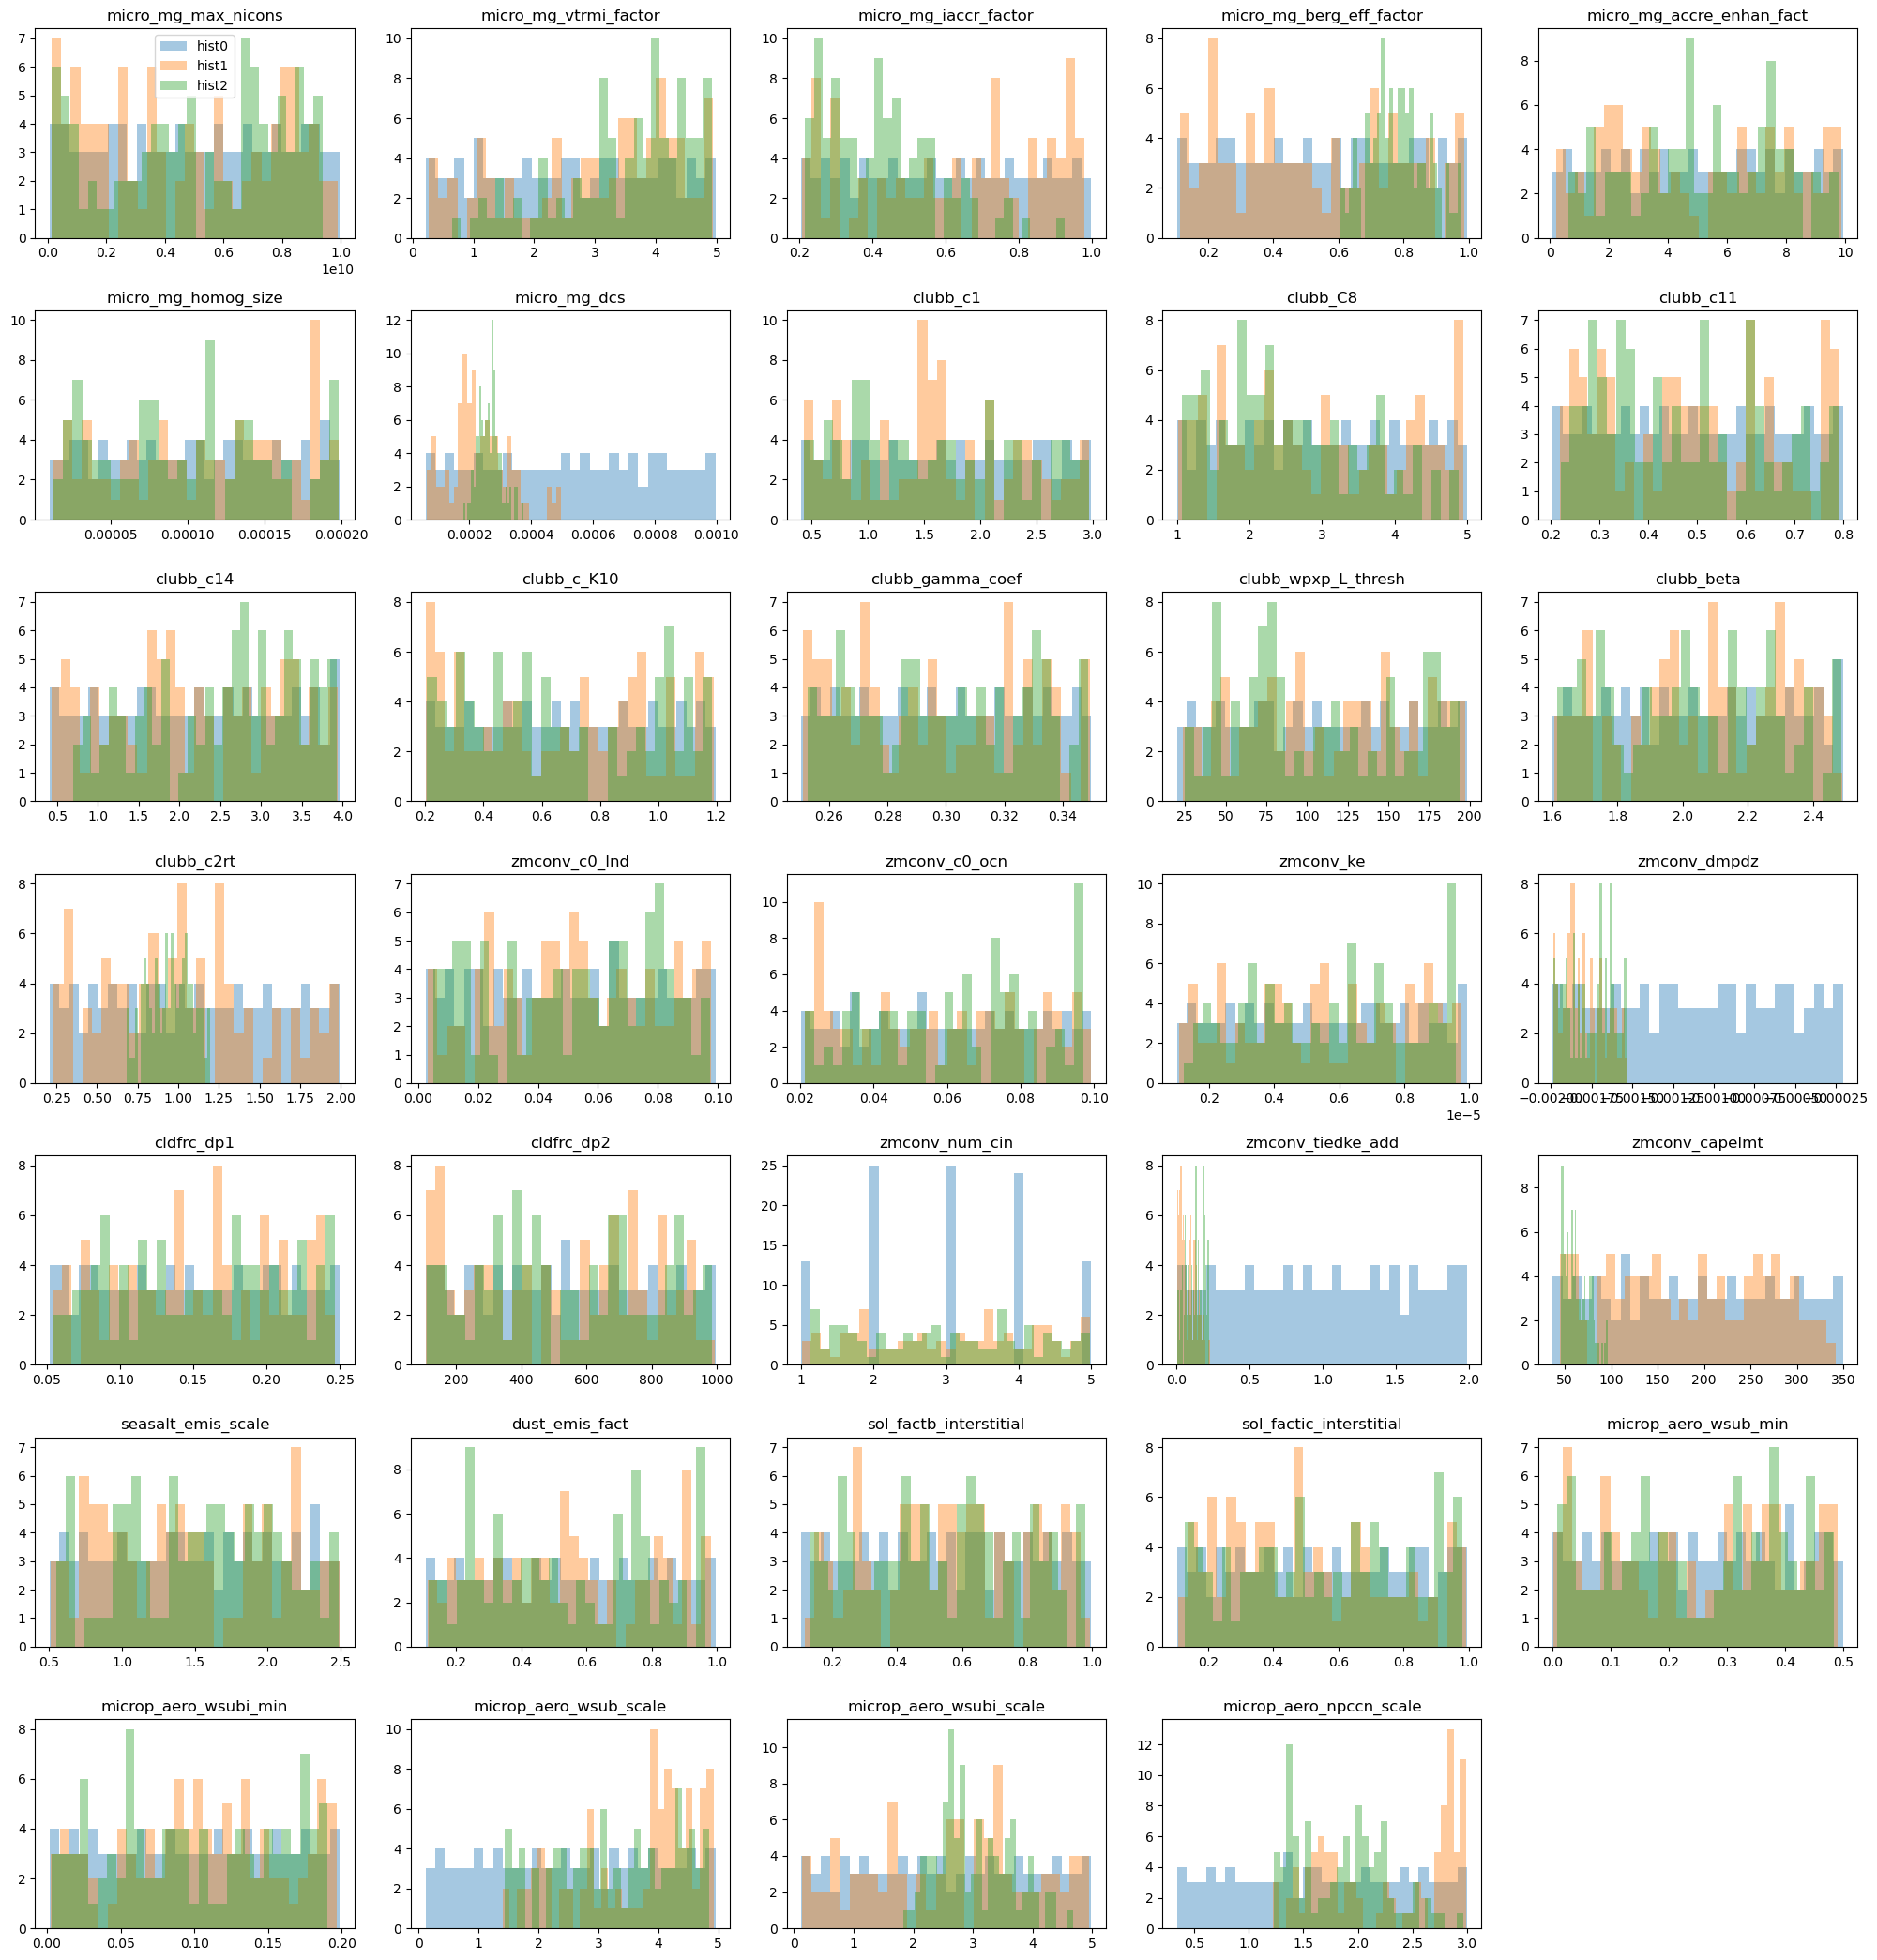

In [17]:
para0 = xr.open_dataset('/glade/work/qingyuany/camml_re/v0/parameter_34_100.nc').to_dataframe().drop(columns = ['Sample_nmb'])
plot_histograms_grid_5([para0, para, test_case.results.realscale_samples.iloc[:100, :]])

In [ ]:
test_case.results.realscale_samples

In [37]:
test_case.save_samples(n = 100)
test_case.write_specifications()

(1000, 34)
['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '

In [53]:
xr.open_dataset('/glade/work/qingyuany/camml_re/v2_extreme/sel_para_realscale.nc')

<xarray.Dataset> Size: 28kB
Dimensions:                    (nmb_sim: 100)
Dimensions without coordinates: nmb_sim
Data variables: (12/35)
    micro_mg_max_nicons        (nmb_sim) float64 800B ...
    micro_mg_vtrmi_factor      (nmb_sim) float64 800B ...
    micro_mg_iaccr_factor      (nmb_sim) float64 800B ...
    micro_mg_berg_eff_factor   (nmb_sim) float64 800B ...
    micro_mg_accre_enhan_fact  (nmb_sim) float64 800B ...
    micro_mg_homog_size        (nmb_sim) float64 800B ...
    ...                         ...
    microp_aero_wsub_min       (nmb_sim) float64 800B ...
    microp_aero_wsubi_min      (nmb_sim) float64 800B ...
    microp_aero_wsub_scale     (nmb_sim) float64 800B ...
    microp_aero_wsubi_scale    (nmb_sim) float64 800B ...
    microp_aero_npccn_scale    (nmb_sim) float64 800B ...
    Sample_nmb                 (nmb_sim) <U3 1kB ...

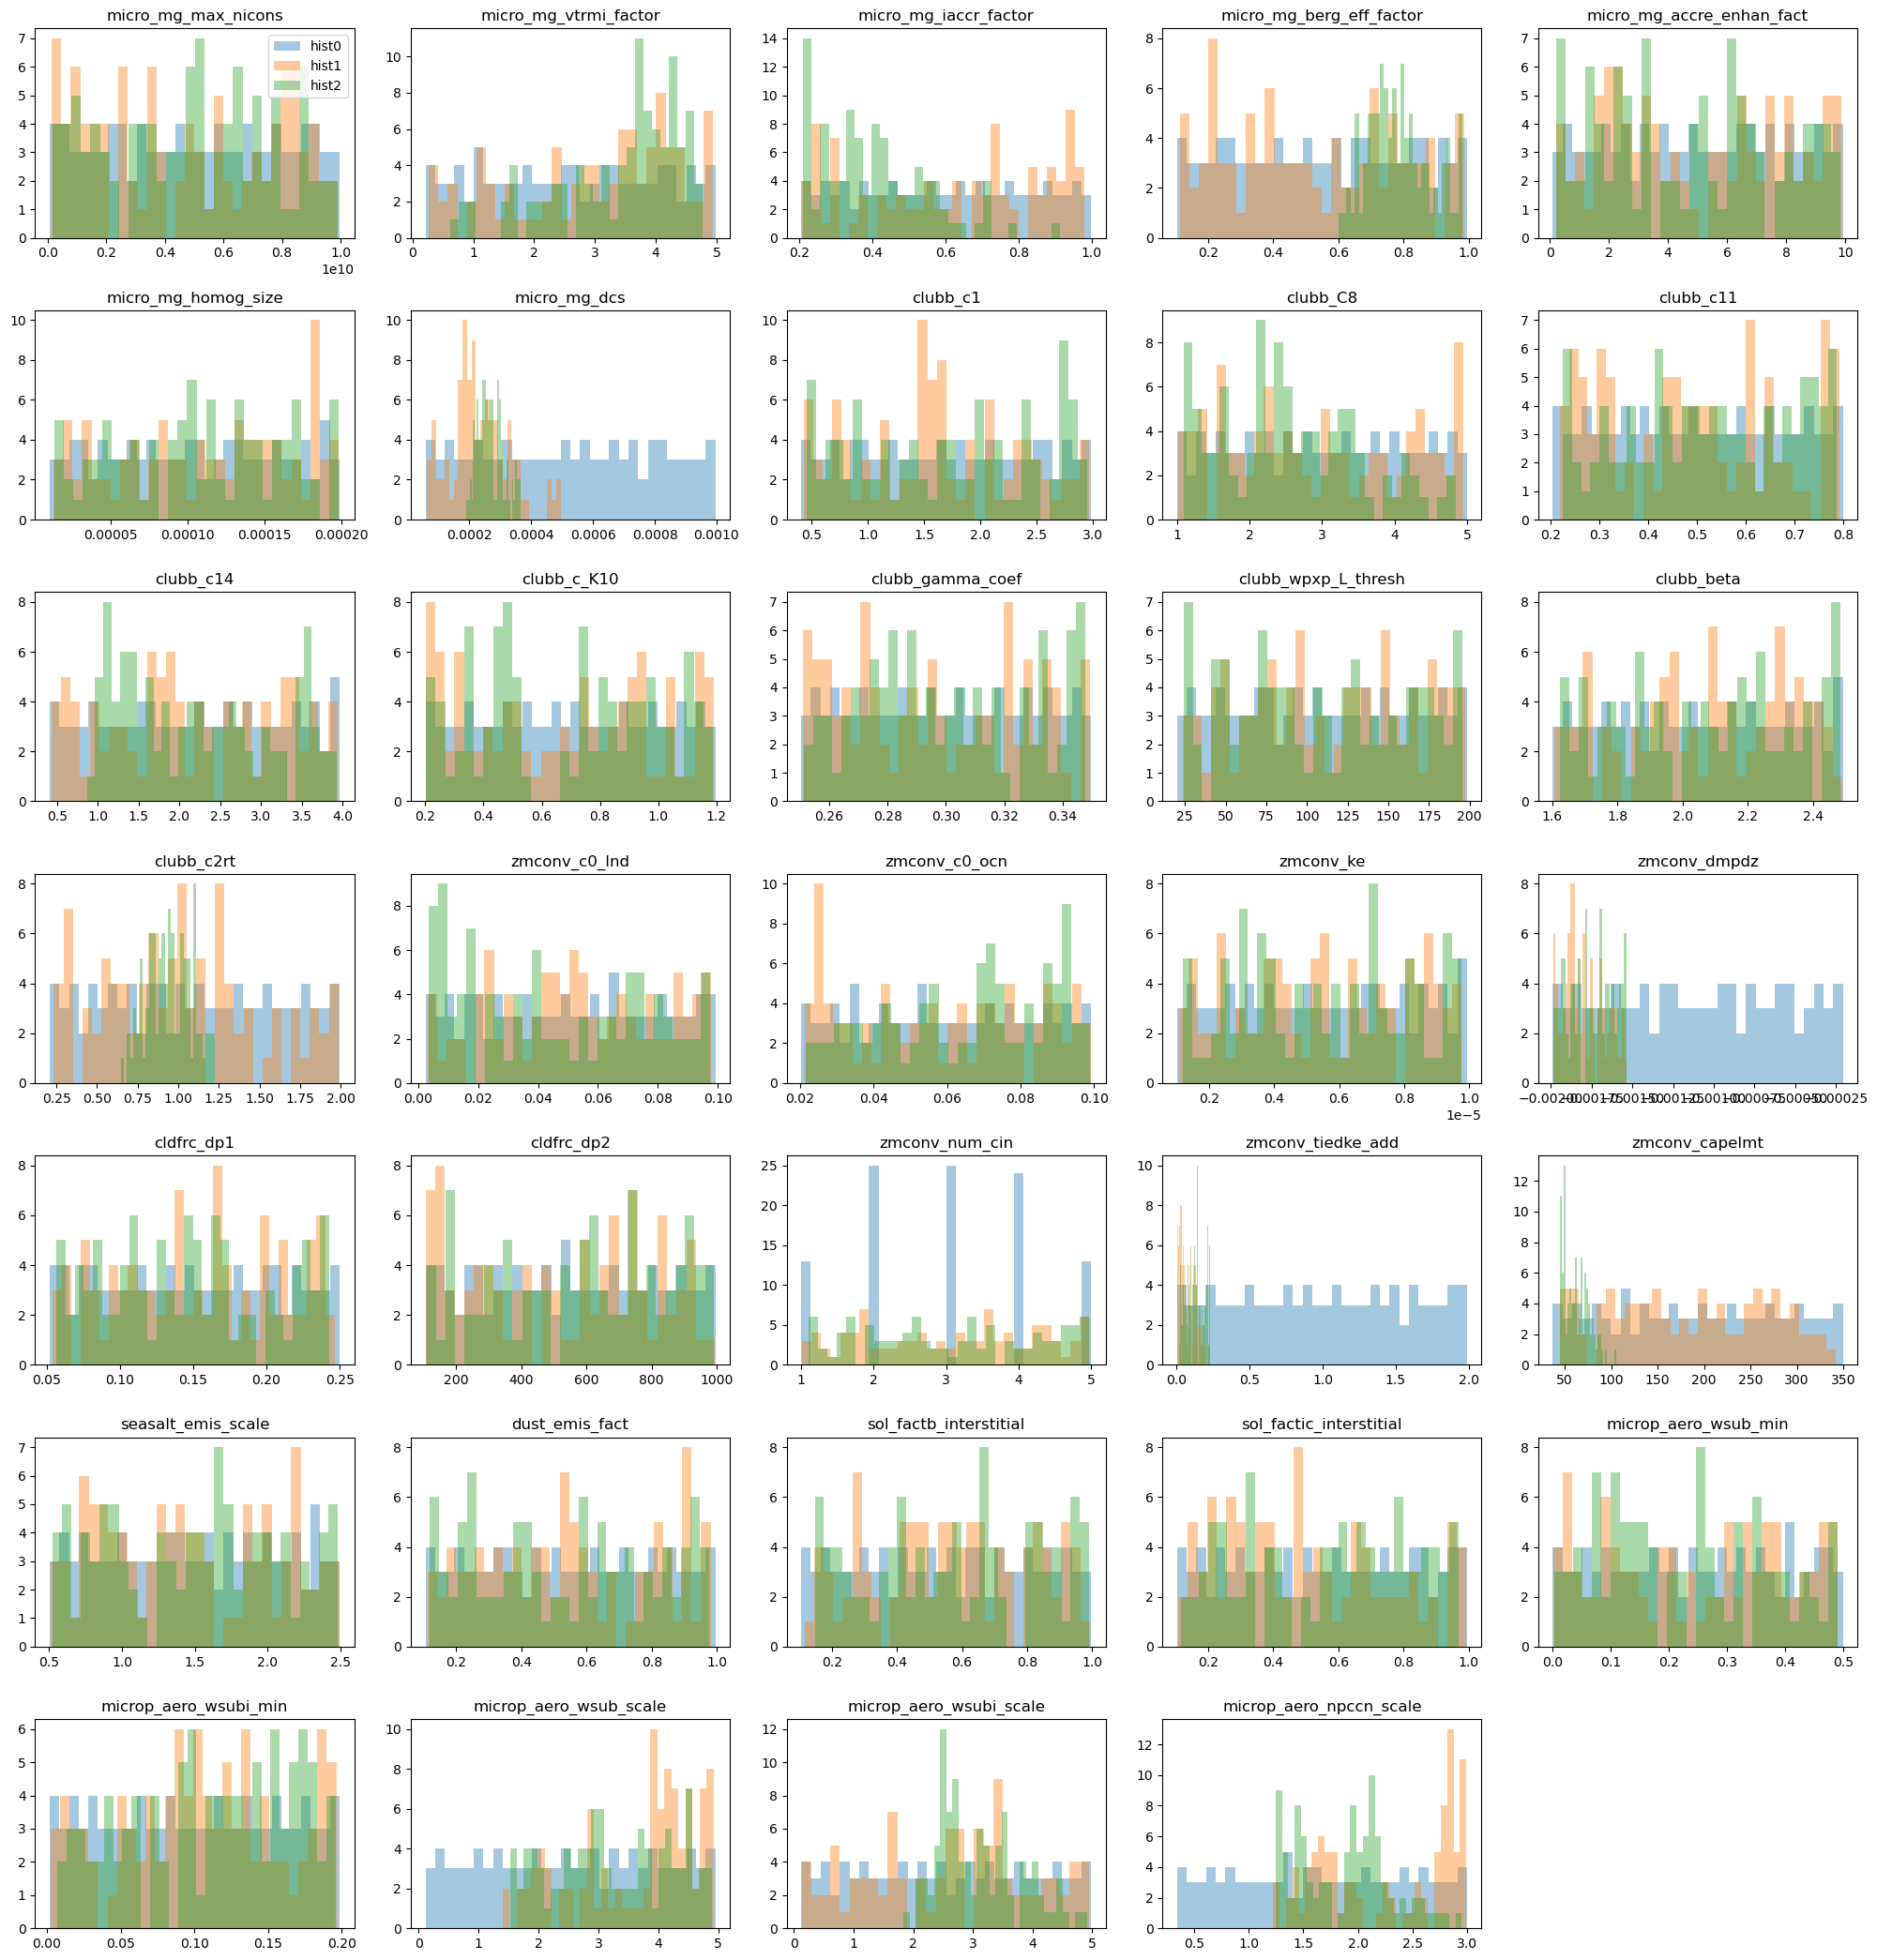

In [46]:
para0

,Sample_nmb,micro_mg_max_nicons,micro_mg_vtrmi_factor,micro_mg_iaccr_factor,micro_mg_berg_eff_factor,micro_mg_accre_enhan_fact,micro_mg_homog_size,micro_mg_dcs,clubb_c1,clubb_C8,...,zmconv_capelmt,seasalt_emis_scale,dust_emis_fact,sol_factb_interstitial,sol_factic_interstitial,microp_aero_wsub_min,microp_aero_wsubi_min,microp_aero_wsub_scale,microp_aero_wsubi_scale,microp_aero_npccn_scale
nmb_sim,,,,,,,,,,,,,,,,,,,,,
0,001,7.215175e+08,1.267022,0.823488,0.407703,1.851045,0.000178,0.000057,0.979179,4.927267,...,120.142934,1.105597,0.277262,0.502497,0.570835,0.041296,0.149827,2.794938,2.535322,1.815058
1,002,9.251974e+09,2.202746,0.889678,0.972194,4.505631,0.000023,0.000122,2.843388,2.428296,...,247.383200,2.407157,0.130452,0.937825,0.529226,0.246292,0.121583,4.902108,3.479043,2.910264
2,003,8.068178e+09,2.323339,0.986899,0.235567,7.137165,0.000153,0.000932,1.953316,1.002911,...,193.238508,1.068723,0.699927,0.769825,0.822189,0.176582,0.072601,1.144683,4.779097,2.030965
3,004,3.647816e+09,3.435071,0.513808,0.591165,5.620052,0.000028,0.000420,2.211190,3.873757,...,244.702000,1.573608,0.492635,0.602469,0.207164,0.468828,0.045972,1.552842,1.753745,2.494477
4,005,4.757067e+09,4.596029,0.509063,0.145424,4.312668,0.000095,0.000769,2.008266,4.541826,...,137.376485,0.891367,0.742055,0.531384,0.460259,0.190384,0.004235,2.608563,2.328749,2.951035
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,096,2.661275e+08,3.304371,0.836747,0.741553,2.671713,0.000104,0.000446,1.078126,1.094893,...,260.229482,1.952411,0.840636,0.545733,0.638349,0.223556,0.158511,2.836542,0.206552,2.616847
96,097,3.716642e+09,1.167166,0.395525,0.830053,1.321274,0.000195,0.000983,1.369105,2.029970,...,300.029807,2.494319,0.483260,0.508618,0.165473,0.021735,0.074680,0.821566,1.673414,0.615581
97,098,6.423990e+08,2.294843,0.797352,0.360380,5.195998,0.000068,0.000804,2.539905,2.228849,...,46.372127,1.928076,0.901520,0.745363,0.938327,0.321258,0.177249,4.458443,4.986438,0.486167
